<a href="https://colab.research.google.com/github/rizkynovrianti88/car-price-prediction/blob/main/Tugas_Proyek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prediksi Harga Mobil Menggunakan Machine Learning

##📌 Latar Belakang

Industri otomotif memiliki dinamika harga yang dipengaruhi oleh berbagai faktor seperti merek (Brand), tahun produksi (Model_Year), kapasitas mesin (Engine_Size), jarak tempuh (Mileage), jenis bahan bakar (Fuel_Type), dan transmisi (Transmission). Bagi penjual maupun pembeli, menentukan harga mobil yang “fair” seringkali sulit karena banyaknya variabel yang saling memengaruhi.

Di sisi lain, ketersediaan data historis membuka peluang untuk membangun model prediktif yang mampu mengestimasi harga mobil secara lebih objektif. Dengan pendekatan data science, proses penentuan harga dapat dibuat lebih akurat, konsisten, dan berbasis data, sehingga membantu pengambilan keputusan yang lebih baik.

##❓ Rumusan Masalah
Faktor apa saja yang paling berpengaruh terhadap harga mobil?
Bagaimana hubungan antara variabel seperti Mileage, Engine_Size, dan Model_Year terhadap harga?
Apakah data memiliki missing values, outlier, atau inkonsistensi yang perlu dibersihkan sebelum modeling?
Bagaimana membangun model Machine Learning yang mampu memprediksi harga mobil secara akurat?
Bagaimana mengimplementasikan model tersebut menjadi aplikasi sederhana yang dapat digunakan oleh pengguna?

##🎯 Objective (Tujuan)
Melakukan eksplorasi data (EDA) untuk memahami struktur data, distribusi, dan hubungan antar variabel.
Melakukan data cleaning & preprocessing, termasuk:
menangani missing values
menghapus kolom tidak relevan (mis. Car_ID)
menangani outlier
Mengidentifikasi fitur penting yang berpengaruh terhadap harga mobil.
Membangun model Machine Learning (mis. Random Forest) untuk memprediksi harga mobil.
Mengevaluasi performa model menggunakan metrik seperti RMSE atau R².
Mengembangkan aplikasi berbasis Streamlit agar model dapat digunakan secara interaktif oleh pengguna.

#DATA OVERVIEW

##Import library & Load Data

In [4]:
# Standard libraries for data analysis:
import numpy as np
import pandas as pd
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix
from scipy.stats import norm, skew

# sklearn modules for data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# sklearn modules for Model Selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# sklearn modules for Model Evaluation & Improvement
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, precision_score,
    recall_score, fbeta_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import (
    cross_val_score, GridSearchCV, ShuffleSplit, KFold
)

# Standard libraries for data visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
%matplotlib inline
color = sns.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display

# Miscellaneous Utilitiy Libraries
import random
from datetime import datetime
import string

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
# Import the dataset
file_dir = '/content/drive/MyDrive/car_price_dataset.csv' # Sesuaikan!
dataset = pd.read_csv(file_dir)

In [7]:
# Read Dataset
display(dataset)

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35
...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,Hyundai,2023,4.5,Diesel,Manual,155033,2,3,310,61734.35
1996,1997,Toyota,2023,1.4,Petrol,Manual,25044,2,4,271,48467.80
1997,1998,Hyundai,2022,4.1,Diesel,Manual,104372,4,3,191,55714.40
1998,1999,BMW,2020,4.4,Diesel,Automatic,158047,4,1,186,53222.65


In [8]:
# Evaluate data structure
dataset.describe()

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,2013.963000,2.967550,100736.956500,2.988000,2.532500,235.70950,46169.507675
std,577.494589,5.508248,1.146926,56002.915221,0.818041,1.125423,95.59811,9211.685713
min,1.000000,2005.000000,1.000000,5036.000000,2.000000,1.000000,70.00000,18911.550000
25%,500.750000,2009.000000,2.000000,52365.500000,2.000000,2.000000,154.00000,39764.000000
50%,1000.500000,2014.000000,2.900000,100590.500000,3.000000,3.000000,236.00000,46112.350000
75%,1500.250000,2019.000000,4.000000,148024.500000,4.000000,4.000000,319.00000,52471.387500
max,2000.000000,2023.000000,5.000000,199904.000000,4.000000,4.000000,399.00000,72267.800000


In [9]:
dataset.dtypes

,0
Car_ID,int64
Brand,object
Model_Year,int64
Engine_Size,float64
Fuel_Type,object
Transmission,object
Mileage,int64
Doors,int64
Owner_Count,int64
Horsepower,int64


###Recheck Column Datatypes and Missing Values

In [10]:
print("Missing values per column:")
display(dataset.isnull().sum())

Missing values per column:


,0
Car_ID,0
Brand,0
Model_Year,0
Engine_Size,0
Fuel_Type,0
Transmission,0
Mileage,0
Doors,0
Owner_Count,0
Horsepower,0


In [11]:
print("Column datatypes:")
display(dataset.dtypes)

Column datatypes:


,0
Car_ID,int64
Brand,object
Model_Year,int64
Engine_Size,float64
Fuel_Type,object
Transmission,object
Mileage,int64
Doors,int64
Owner_Count,int64
Horsepower,int64


##Load & Overview

In [20]:
df = pd.read_csv(file_dir)

print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe())

Shape: (2000, 11)


,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB


None

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,2013.963000,2.967550,100736.956500,2.988000,2.532500,235.70950,46169.507675
std,577.494589,5.508248,1.146926,56002.915221,0.818041,1.125423,95.59811,9211.685713
min,1.000000,2005.000000,1.000000,5036.000000,2.000000,1.000000,70.00000,18911.550000
25%,500.750000,2009.000000,2.000000,52365.500000,2.000000,2.000000,154.00000,39764.000000
50%,1000.500000,2014.000000,2.900000,100590.500000,3.000000,3.000000,236.00000,46112.350000
75%,1500.250000,2019.000000,4.000000,148024.500000,4.000000,4.000000,319.00000,52471.387500
max,2000.000000,2023.000000,5.000000,199904.000000,4.000000,4.000000,399.00000,72267.800000


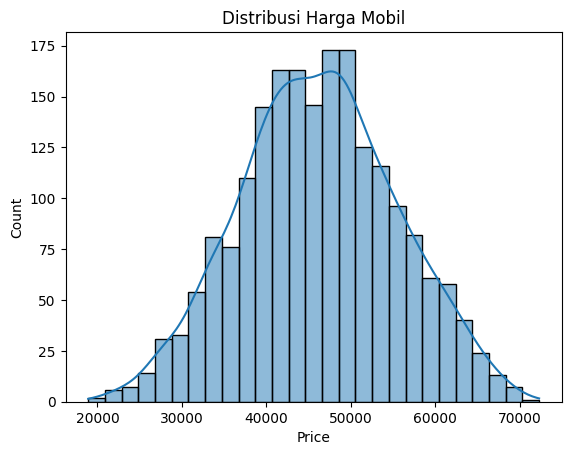

In [21]:
# Distribusi target
sns.histplot(df["Price"], kde=True)
plt.title("Distribusi Harga Mobil")
plt.show()

#DATA HANDLING (cleaning + preprocessing)

In [22]:
df = dataset.copy()
# ======================
# DROP KOLOM TIDAK PERLU
# ======================
if "Car_ID" in df.columns:
    df = df.drop(columns=["Car_ID"])

# ======================
# HANDLE MISSING VALUES
# ======================
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ======================
# RAPPIKAN TEKS
# ======================
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

# ======================
# HANDLE OUTLIER (IQR)
# ======================
def handle_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[column] = np.clip(data[column], lower, upper)
    return data

for col in num_cols:
    df = handle_outliers_iqr(df, col)

# ======================
# OPTIONAL: TRANSFORM TARGET
# ======================
if df["Price"].skew() > 1:
    df["Price"] = np.log1p(df["Price"])

print("✅ Data handling selesai")
df.head()

✅ Data handling selesai


,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,Bmw,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


#EDA (Visualisasi)

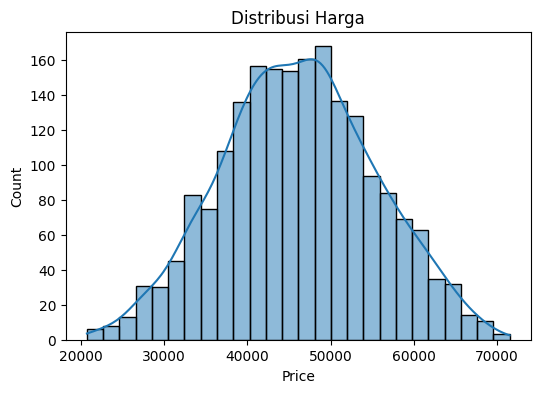

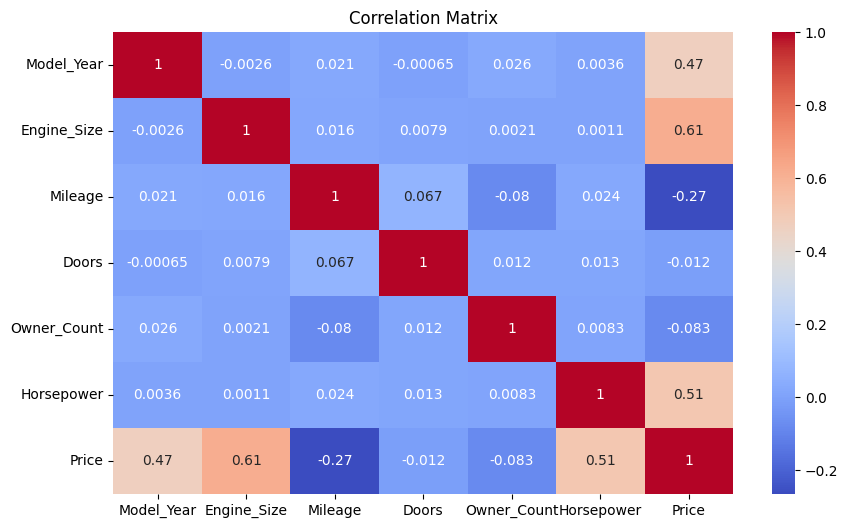

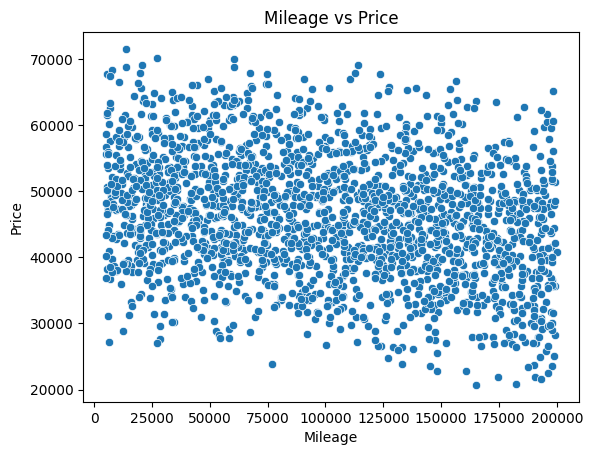

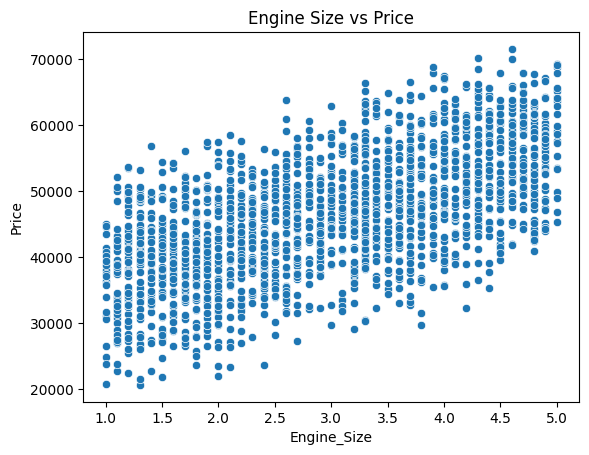

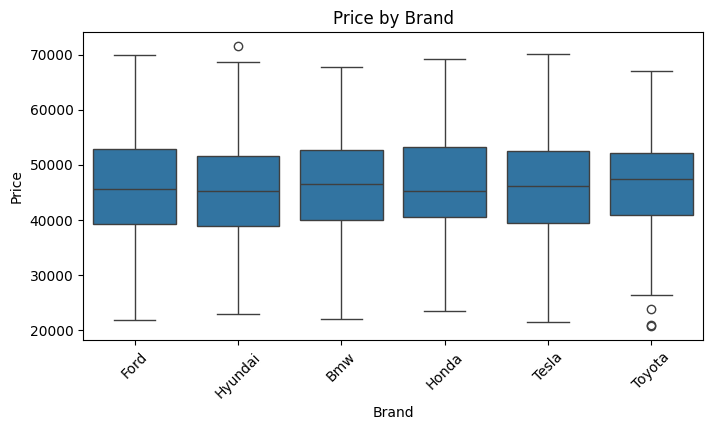

In [23]:
# Distribusi harga
plt.figure(figsize=(6,4))
sns.histplot(df["Price"], kde=True)
plt.title("Distribusi Harga")
plt.show()

# Korelasi numerik
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Scatter penting
sns.scatterplot(x="Mileage", y="Price", data=df)
plt.title("Mileage vs Price")
plt.show()

sns.scatterplot(x="Engine_Size", y="Price", data=df)
plt.title("Engine Size vs Price")
plt.show()

# Kategori
plt.figure(figsize=(8,4))
sns.boxplot(x="Brand", y="Price", data=df)
plt.xticks(rotation=45)
plt.title("Price by Brand")
plt.show()

In [25]:
import pandas as pd
#Encoding dan Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define X and y BEFORE using X
X = df.drop("Price", axis=1)
y = df["Price"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

In [26]:
#Membangun Model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor())
])

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Brand', 'Fuel_Type', 'Transmission'], dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Model_Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count',
       'Horsepower'],
      dtype='object'))])),
                ('model', RandomForestRegressor())])

In [27]:
#Mengevaluasi Hasil Pemodelan
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 2453.5580928380296
R2: 0.9245030968462848


In [30]:
df.to_csv("clean_car_data.csv", index=False)
from google.colab import files
files.download("clean_car_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import pandas as pd
# Instead of reading from file, use the 'df' DataFrame directly as it's already in memory
cleaned_df = df.copy() # Assuming 'df' is available from previous cells
display(cleaned_df.head())

,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,Bmw,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


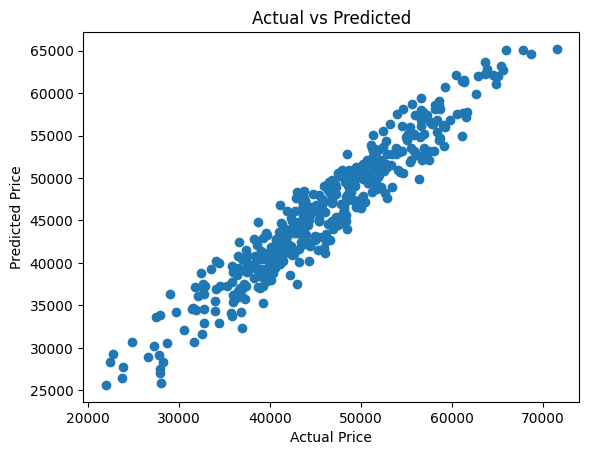

In [31]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

# Re-initialize X and y (assuming 'df' is available from previous cells)
X = df.drop("Price", axis=1)
y = df["Price"]

# Re-run train_test_split to get y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-define preprocessor (assuming 'df' is available and its columns)
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Re-define and fit model
model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])
model.fit(X_train, y_train)

# Re-make prediction to get y_pred
y_pred = model.predict(X_test)

# Now plot with defined y_test and y_pred
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()